# 三种相机触发的时间分布

本 notebook 使用同一个真实 CORSIKA 事件（默认 `event 1909 / telescope 19`）分别重建：

1. 旧 p.e. 触发：饱和前 `Primary p.e.`；
2. 电子学 p.e.-count 触发：饱和后 `Fired p.e.`；
3. 电子学 mV 触发：单 p.e. 模板叠加后的 4 ns 波形；
4. 纯 NSB：独立运行结果，单独成图，不与切伦科夫信号叠加。

每张图依次给出相机总时间分布、最强像素时间热图和滑窗中过阈值像素数。虚线表示相机 multiplicity 阈值，阴影表示最早满足触发条件的时间窗。

## 1. 参数

In [1]:
EVENT_ID = 1909
TELESCOPE_ID = 19

TIME_START_NS = -20.0
TIME_END_NS = 100.0
SAMPLE_WIDTH_NS = 4.0
WINDOW_NS = 20.0

# 三种模式使用各自当前示例 cfg 的阈值。
OLD_PE_THRESHOLD = 5.0
OLD_PE_MULTIPLICITY = 3
PE_COUNT_THRESHOLD = 2.0
PE_COUNT_MULTIPLICITY = 2
MV_THRESHOLD = 2.0
MV_MULTIPLICITY = 2

TOP_PIXELS = 12

## 2. 读取真实电子学输出

In [2]:
from pathlib import Path
import json

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import uproot
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'configs').is_dir() and (candidate / 'validation').is_dir():
            return candidate
    raise RuntimeError('cannot locate LACT_sim repository root')


REPO_ROOT = find_repo_root(Path.cwd())
ROOT_PATH = REPO_ROOT / 'validation/electronics_chain_v2/validation_outputs/gamma_e2e/lact_events.root'
NSB_DIR = REPO_ROOT / 'validation/electronics_chain_v2/trigger_time_distributions_data/nsb'
FIGURE_DIR = REPO_ROOT / 'validation/electronics_chain_v2/trigger_time_distributions'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

root_file = uproot.open(ROOT_PATH)
camera = root_file['camera_pixels'].arrays(library='np')
primary_hits = root_file['primary_pe_hits'].arrays(library='np')
fired_hits = root_file['fired_pe_hits'].arrays(library='np')
waveforms = root_file['waveforms'].arrays(library='ak')

pixel_axis = np.asarray(camera['pixel_id'], dtype=int)
pixel_to_row = {int(pixel_id): row for row, pixel_id in enumerate(pixel_axis)}
time_edges_ns = np.arange(TIME_START_NS, TIME_END_NS + SAMPLE_WIDTH_NS, SAMPLE_WIDTH_NS)
time_centers_ns = 0.5 * (time_edges_ns[:-1] + time_edges_ns[1:])
n_bins = len(time_centers_ns)

print('ROOT:', ROOT_PATH)
print('event/telescope:', EVENT_ID, TELESCOPE_ID)
print('camera pixels:', len(pixel_axis), 'time bins:', n_bins)

ROOT: E:\LACT_pylast\LACT_sim_electronics_v2_20260731\validation\electronics_chain_v2\validation_outputs\gamma_e2e\lact_events.root
event/telescope: 1909 19
camera pixels: 1664 time bins: 30


## 3. 公共计算与绘图函数

In [3]:
BLUE = '#1f77b4'
ORANGE = '#e67e22'
DARK = '#30343b'
LIGHT = '#d9e8f5'


def hit_matrix(hit_tree, value_name):
    matrix = np.zeros((len(pixel_axis), n_bins), dtype=float)
    mask = (
        (np.asarray(hit_tree['event_id']) == EVENT_ID)
        & (np.asarray(hit_tree['telescope_id']) == TELESCOPE_ID)
    )
    pixels = np.asarray(hit_tree['pixel_id'][mask], dtype=int)
    times = np.asarray(hit_tree['time_ns'][mask], dtype=float)
    values = np.asarray(hit_tree[value_name][mask], dtype=float)
    bins = np.floor((times - TIME_START_NS) / SAMPLE_WIDTH_NS).astype(int)
    valid = (bins >= 0) & (bins < n_bins)
    rows = np.asarray([pixel_to_row[int(pixel)] for pixel in pixels[valid]], dtype=int)
    np.add.at(matrix, (rows, bins[valid]), values[valid])
    return matrix


def root_waveform_matrix():
    matrix = np.zeros((len(pixel_axis), n_bins), dtype=float)
    mask = (
        (np.asarray(waveforms.event_id) == EVENT_ID)
        & (np.asarray(waveforms.telescope_id) == TELESCOPE_ID)
    )
    indices = np.flatnonzero(mask)
    if len(indices) != 1:
        raise RuntimeError(f'expected one waveform row, found {len(indices)}')
    row = waveforms[int(indices[0])]
    for pixel, time_bin, value in zip(
        np.asarray(row.pixel_id, dtype=int),
        np.asarray(row.time_bin, dtype=int),
        np.asarray(row.sample_value, dtype=float),
    ):
        if int(pixel) in pixel_to_row and 0 <= time_bin < n_bins:
            matrix[pixel_to_row[int(pixel)], time_bin] += value
    return matrix


def trigger_curve(matrix, threshold, multiplicity, mode, timing=None):
    window_bins = max(1, int(np.ceil(WINDOW_NS / SAMPLE_WIDTH_NS)))
    pixels_above = np.zeros(n_bins, dtype=int)
    for end in range(n_bins):
        start = max(0, end + 1 - window_bins)
        window = matrix[:, start:end + 1]
        if mode == 'count':
            crossed = window.sum(axis=1) >= threshold
        elif mode == 'voltage':
            crossed = np.any(window >= threshold, axis=1)
        else:
            raise ValueError(mode)
        pixels_above[end] = int(np.count_nonzero(crossed))

    triggered_bins = np.flatnonzero(pixels_above >= multiplicity)
    triggered = len(triggered_bins) > 0
    first_end = int(triggered_bins[0]) if triggered else None
    trigger_time = np.nan
    if triggered:
        trigger_time = time_centers_ns[first_end]
    return pixels_above, first_end, trigger_time, window_bins


def plot_mode(
    matrix, *, title, unit, threshold, multiplicity, mode, output_name,
    x_label='time relative to first Cherenkov p.e. [ns]'
):
    pixels_above, first_end, trigger_time, window_bins = trigger_curve(
        matrix, threshold, multiplicity, mode
    )
    if mode == 'voltage':
        ranking = matrix.max(axis=1)
    else:
        ranking = matrix.sum(axis=1)
    top_rows = np.argsort(ranking)[-TOP_PIXELS:][::-1]

    fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True,
                             gridspec_kw={'height_ratios': [1.0, 2.0, 1.0]})
    axes[0].step(time_centers_ns, matrix.sum(axis=0), where='mid', color=BLUE, lw=1.8)
    axes[0].set_ylabel(f'camera sum [{unit}]')
    axes[0].grid(alpha=0.22)

    image = axes[1].imshow(
        matrix[top_rows], aspect='auto', origin='upper', interpolation='nearest',
        extent=[TIME_START_NS, TIME_END_NS, TOP_PIXELS - 0.5, -0.5], cmap='viridis'
    )
    axes[1].set_yticks(np.arange(TOP_PIXELS), pixel_axis[top_rows])
    axes[1].set_ylabel('top pixel id')
    colorbar = fig.colorbar(image, ax=axes[1], pad=0.015)
    colorbar.set_label(unit)

    axes[2].step(time_centers_ns, pixels_above, where='mid', color=ORANGE, lw=1.8)
    axes[2].axhline(multiplicity, color=DARK, ls='--', lw=1.4,
                    label=f'camera multiplicity = {multiplicity}')
    if first_end is not None:
        window_stop = time_centers_ns[first_end] + 0.5 * SAMPLE_WIDTH_NS
        window_start = max(TIME_START_NS, window_stop - WINDOW_NS)
        axes[2].axvspan(window_start, window_stop, color=LIGHT, alpha=0.55,
                        label='first accepted window')
        axes[2].axvline(trigger_time, color=BLUE, ls=':', lw=1.5,
                        label=f'trigger time = {trigger_time:.1f} ns')
    axes[2].set_ylabel('pixels above threshold\nin previous 20 ns')
    axes[2].set_xlabel(x_label)
    axes[2].grid(alpha=0.22)
    axes[2].legend(loc='upper right', frameon=False)

    fig.suptitle(title, fontsize=14)
    fig.text(0.5, 0.94,
             f'pixel threshold = {threshold:g} {unit}; window = {WINDOW_NS:g} ns; '
             f'triggered = {first_end is not None}',
             ha='center', color=DARK)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    output_path = FIGURE_DIR / output_name
    fig.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()
    return {
        'mode': title,
        'threshold': threshold,
        'threshold_unit': unit,
        'multiplicity': multiplicity,
        'window_ns': WINDOW_NS,
        'triggered': first_end is not None,
        'trigger_time_ns': trigger_time,
        'max_pixels_above_threshold': int(pixels_above.max()),
        'figure': str(output_path.relative_to(REPO_ROOT)),
    }

## 4. 旧 p.e. 触发

使用饱和前 `Primary p.e.`。这里采用原有示例触发参数：单像素 5 p.e.、至少 3 个像素、20 ns 窗口。横坐标表示当前判定时刻，窗口只读取此前已经到达的样本。

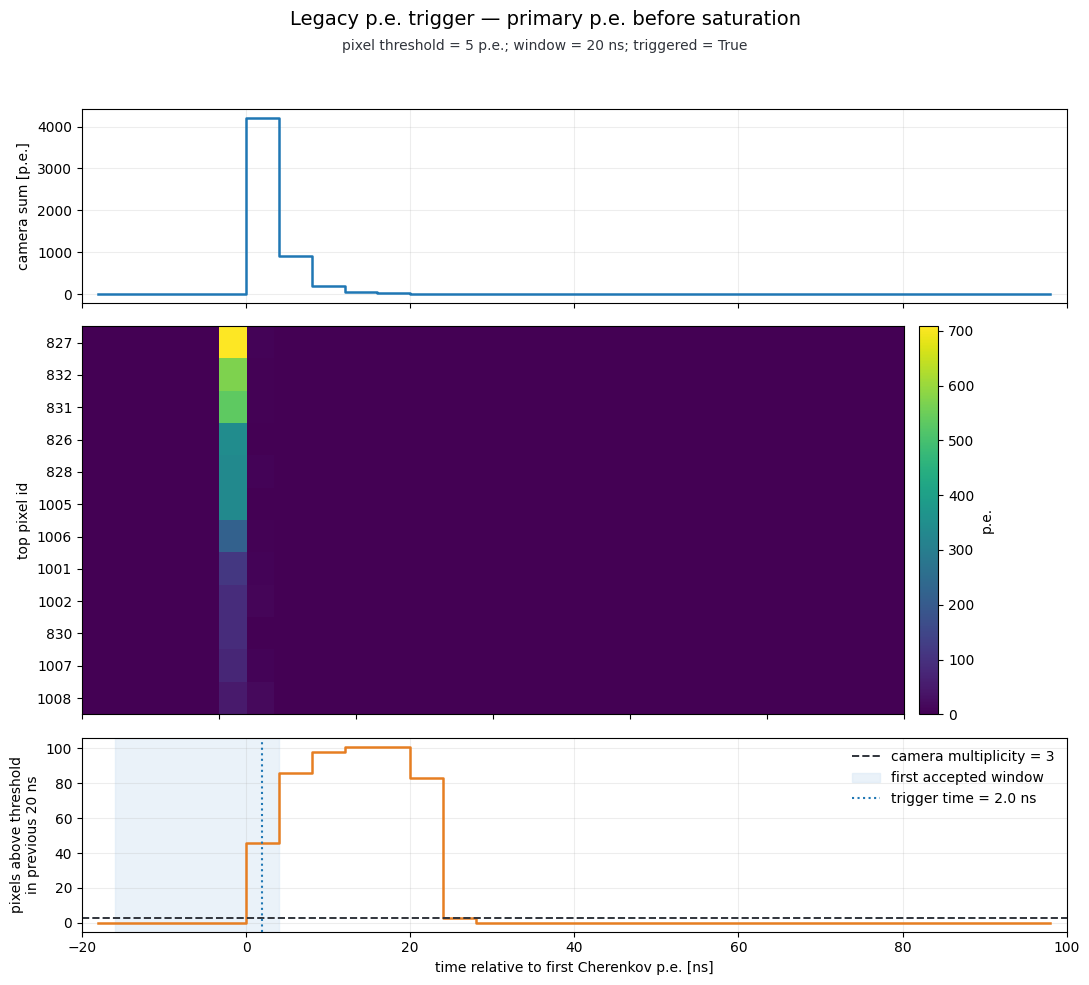

In [4]:
primary_matrix = hit_matrix(primary_hits, 'primary_pe')
old_pe_summary = plot_mode(
    primary_matrix,
    title='Legacy p.e. trigger — primary p.e. before saturation',
    unit='p.e.', threshold=OLD_PE_THRESHOLD,
    multiplicity=OLD_PE_MULTIPLICITY, mode='count',
    output_name='01_legacy_pe_trigger.png'
)

## 5. 电子学 p.e.-count 触发

使用微单元 gap 与饱和之后的 `Fired p.e.`。不要求生成单 p.e. 模板；当前示例参数为单像素 2 p.e.、至少 2 个像素、20 ns 窗口。

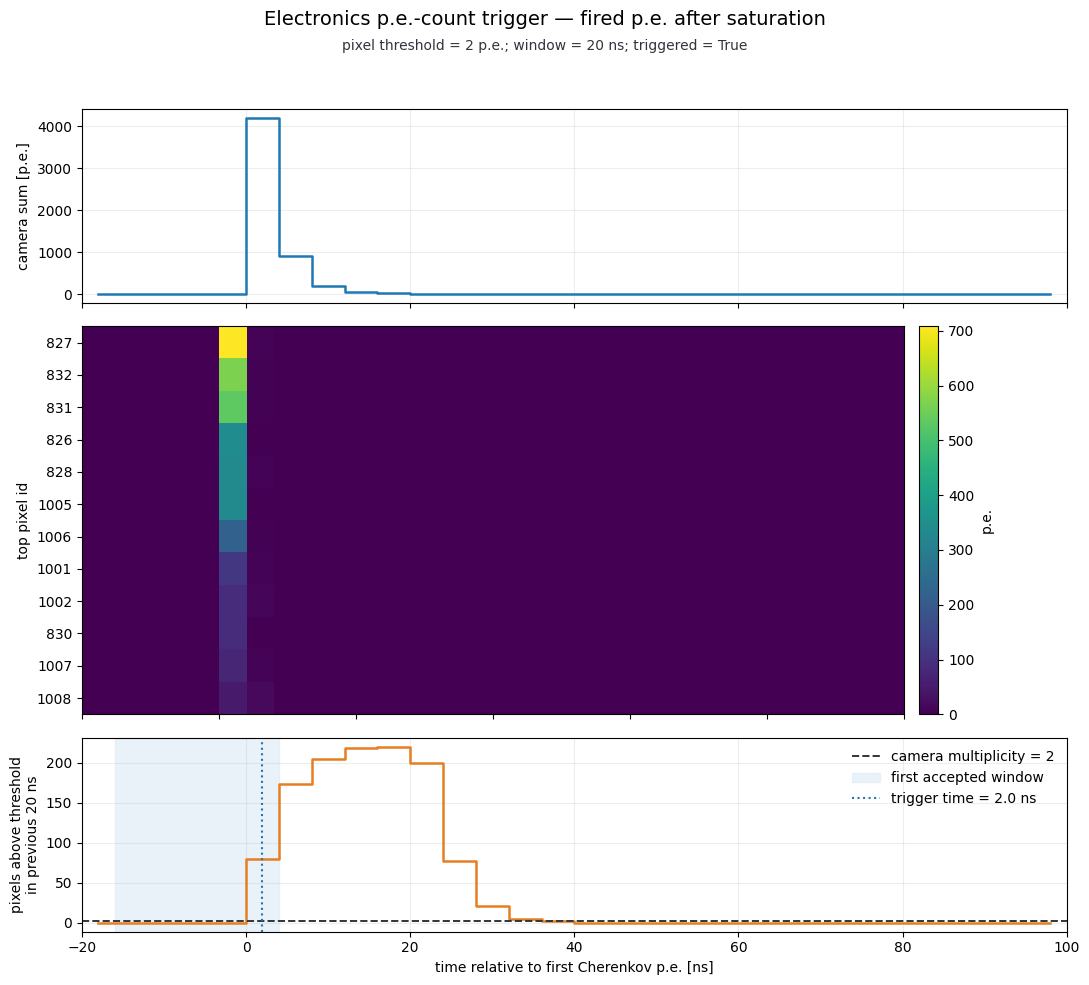

In [5]:
fired_matrix = hit_matrix(fired_hits, 'fired_pe')
pe_count_summary = plot_mode(
    fired_matrix,
    title='Electronics p.e.-count trigger — fired p.e. after saturation',
    unit='p.e.', threshold=PE_COUNT_THRESHOLD,
    multiplicity=PE_COUNT_MULTIPLICITY, mode='count',
    output_name='02_pe_count_trigger.png'
)

## 6. 电子学 mV 触发

使用 Fired p.e. 叠加单 p.e. 模板并完成 8 通道求和后的像素波形。像素在20 ns窗口内只要有一个4 ns采样点超过2 mV就算过阈值；随后仍要求至少2个像素同时满足条件。

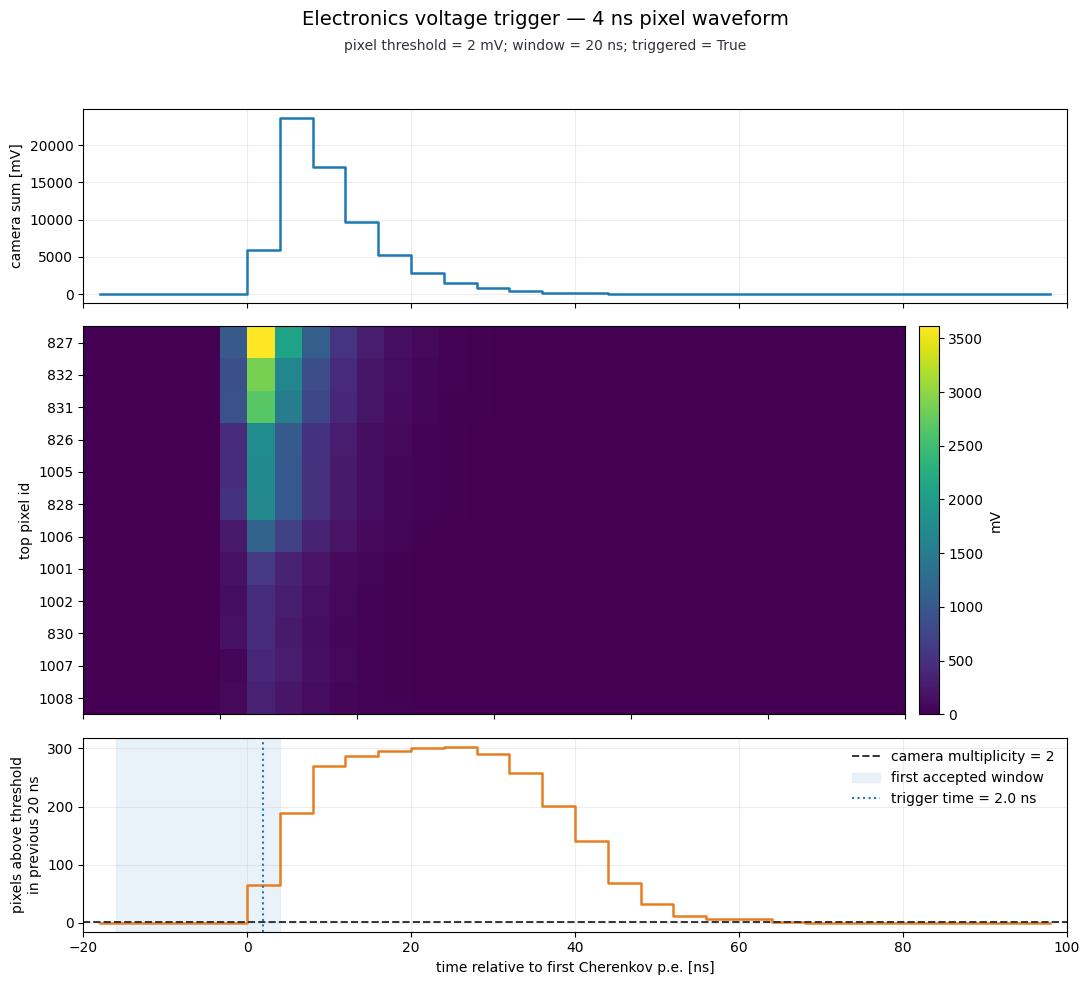

In [6]:
mv_matrix = root_waveform_matrix()
mv_summary = plot_mode(
    mv_matrix,
    title='Electronics voltage trigger — 4 ns pixel waveform',
    unit='mV', threshold=MV_THRESHOLD,
    multiplicity=MV_MULTIPLICITY, mode='voltage',
    output_name='03_mv_trigger.png'
)

## 7. 纯 NSB（独立图）

这张图只读取独立 NSB 运行结果，不叠加 event 1909 的切伦科夫信号。它使用与 mV 示例相同的2 mV、2像素、20 ns触发设置。

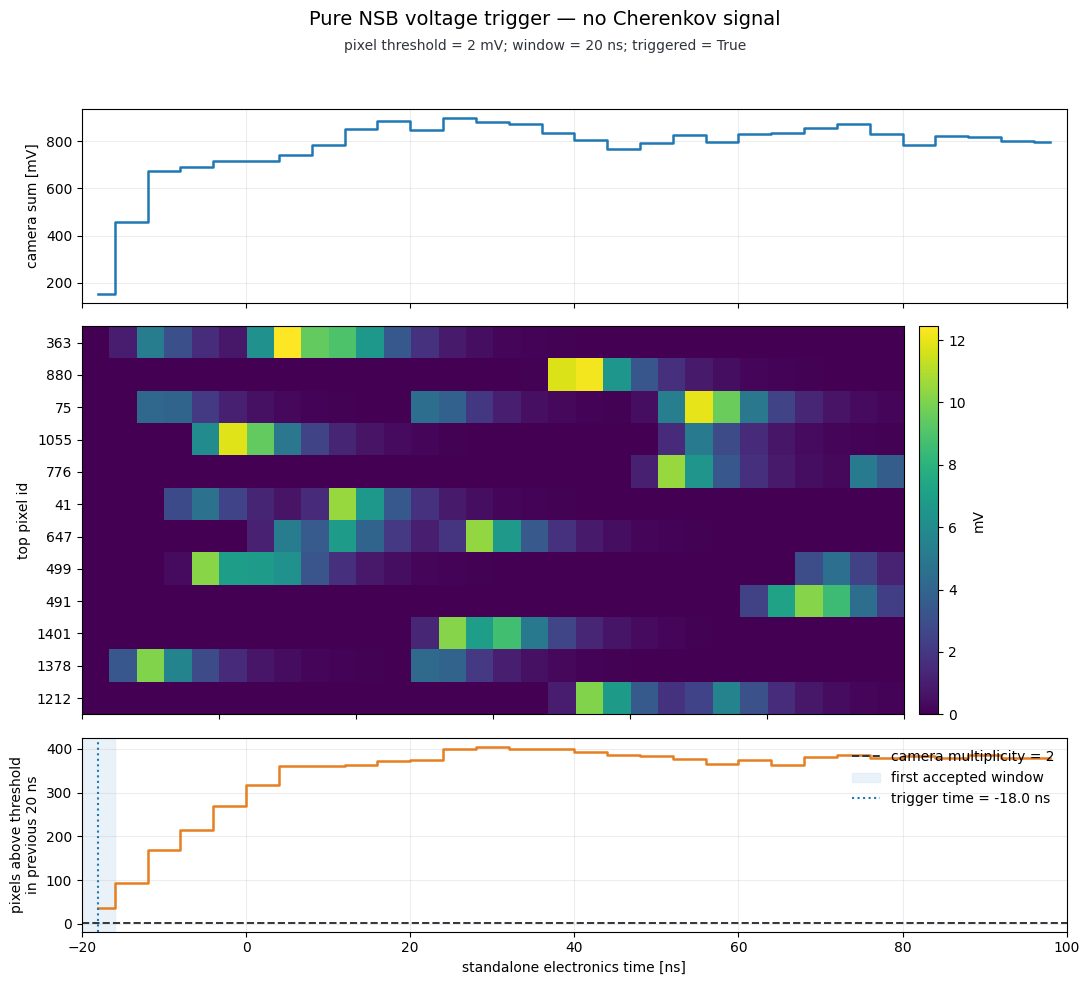

In [7]:
with open(NSB_DIR / 'metadata.json', encoding='utf-8') as stream:
    nsb_metadata = json.load(stream)
nsb_waveform = pd.read_csv(NSB_DIR / 'waveform.csv')
nsb_trigger = pd.read_csv(NSB_DIR / 'trigger.csv').iloc[0]

nsb_pixels = np.arange(int(nsb_metadata['n_pixels']), dtype=int)
nsb_matrix = np.zeros((len(nsb_pixels), n_bins), dtype=float)
valid = (
    nsb_waveform.pixel_id.between(0, len(nsb_pixels) - 1)
    & nsb_waveform.time_bin.between(0, n_bins - 1)
)
np.add.at(
    nsb_matrix,
    (
        nsb_waveform.loc[valid, 'pixel_id'].to_numpy(dtype=int),
        nsb_waveform.loc[valid, 'time_bin'].to_numpy(dtype=int),
    ),
    nsb_waveform.loc[valid, 'sample_value'].to_numpy(dtype=float),
)

# plot_mode uses the real 1664-pixel camera axis for labels; both axes are 0..1663.
nsb_summary = plot_mode(
    nsb_matrix,
    title='Pure NSB voltage trigger — no Cherenkov signal',
    unit='mV', threshold=MV_THRESHOLD,
    multiplicity=MV_MULTIPLICITY, mode='voltage',
    output_name='04_nsb_voltage_trigger.png',
    x_label='standalone electronics time [ns]'
)
assert bool(nsb_summary['triggered']) == bool(nsb_trigger['triggered'])
assert np.isclose(nsb_summary['trigger_time_ns'], float(nsb_trigger['trigger_time_ns']))

## 8. 数值汇总与检查

In [8]:
summary = pd.DataFrame([
    old_pe_summary,
    pe_count_summary,
    mv_summary,
    nsb_summary,
])
display(summary)

assert primary_matrix.sum() == 5399
assert fired_matrix.sum() == 5396
assert primary_matrix.sum() - fired_matrix.sum() == 3
assert summary.triggered.all()
print('检查通过：同一切伦科夫事件的三种触发均触发；纯 NSB 独立触发结果与程序输出一致。')

,mode,threshold,threshold_unit,multiplicity,window_ns,triggered,trigger_time_ns,max_pixels_above_threshold,figure
0,Legacy p.e. trigger — primary p.e. before satu...,5.0,p.e.,3,20.0,True,2.0,101,validation\electronics_chain_v2\trigger_time_d...
1,Electronics p.e.-count trigger — fired p.e. af...,2.0,p.e.,2,20.0,True,2.0,220,validation\electronics_chain_v2\trigger_time_d...
2,Electronics voltage trigger — 4 ns pixel waveform,2.0,mV,2,20.0,True,2.0,303,validation\electronics_chain_v2\trigger_time_d...
3,Pure NSB voltage trigger — no Cherenkov signal,2.0,mV,2,20.0,True,-18.0,405,validation\electronics_chain_v2\trigger_time_d...


检查通过：同一切伦科夫事件的三种触发均触发；纯 NSB 独立触发结果与程序输出一致。


## 结论

- 三种模式的相机条件都是“达到单像素阈值的像素数 ≥ multiplicity”；区别只在单像素阈值作用于 Primary p.e.、Fired p.e. 还是 mV 波形。
- `trigger.camera.multiplicity` 可设置为3；当前电子学验证 cfg 使用2，因此图中按2绘制。
- NSB 可以独立开关。这里的纯 NSB 图用于验证流程，不代表最终物理 NSB 参数已经定标。
- ROOT、HDF5、CSV最终应共享同一份触发结果；格式不应改变物理判定。